In [127]:
import torch
import random
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
# context length: how many characters do we take to predict the next one
block_size = 3 
X, Y = [], []
for w in words[:5]:
  context = [0] * block_size
  #print(context)
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    print(''.join(itos[i] for i in context), '---->', itos[ix])
    context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

... ----> e
..e ----> m
.em ----> m
emm ----> a
mma ----> .
... ----> o
..o ----> l
.ol ----> i
oli ----> v
liv ----> i
ivi ----> a
via ----> .
... ----> a
..a ----> v
.av ----> a
ava ----> .
... ----> i
..i ----> s
.is ----> a
isa ----> b
sab ----> e
abe ----> l
bel ----> l
ell ----> a
lla ----> .
... ----> s
..s ----> o
.so ----> p
sop ----> h
oph ----> i
phi ----> a
hia ----> .


In [7]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [75]:
C = torch.randn((27,2))
C.shape

torch.Size([27, 2])

In [12]:
print(C[5])
print(C[[3,4,5,6,9]])
print(C[torch.tensor([3,4,5,6,9])])

tensor([-0.9933,  0.4982])
tensor([[-0.9242,  1.7718],
        [-1.8495, -1.2530],
        [-0.9933,  0.4982],
        [ 0.9058,  0.6123],
        [ 0.9910,  0.4361]])
tensor([[-0.9242,  1.7718],
        [-1.8495, -1.2530],
        [-0.9933,  0.4982],
        [ 0.9058,  0.6123],
        [ 0.9910,  0.4361]])


In [13]:
C[X].shape

torch.Size([32, 3, 2])

In [17]:
print(X[13,2])

tensor(1)


In [15]:
C[X][13,2]

tensor([-0.6571,  0.9646])

In [18]:
C[1]

tensor([-0.6571,  0.9646])

In [19]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [20]:
w1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [21]:
emb @ w1+b1 

RuntimeError: mat1 and mat2 shapes cannot be multiplied (96x2 and 6x100)

In [24]:
emb[:, 0, :].shape, emb[:, 1, :].shape, emb[:, 2, :].shape

(torch.Size([32, 2]), torch.Size([32, 2]), torch.Size([32, 2]))

In [25]:
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape

torch.Size([32, 6])

In [26]:
emb.view(32, 6) @ w1+b1 

tensor([[ 1.0626e+00,  3.7003e-01,  3.4806e+00,  ...,  7.3448e-01,
          6.9474e-01, -1.5486e+00],
        [ 3.2755e+00, -1.5553e+00,  4.4102e-02,  ...,  4.0703e-01,
          3.3268e-01,  3.9983e-01],
        [ 3.3774e+00, -1.4897e-01, -3.6244e+00,  ..., -4.3638e+00,
          2.1389e+00,  3.0619e+00],
        ...,
        [ 2.0245e+00,  1.3798e+00,  6.7659e-01,  ..., -1.5311e+00,
          5.4486e-02,  2.1818e-01],
        [-1.7878e+00, -3.4887e-01,  3.2000e+00,  ...,  2.0535e+00,
          1.0137e-01, -2.1439e+00],
        [ 3.0792e+00,  2.5393e-01,  1.3548e+00,  ...,  3.7936e-01,
          3.9386e-03, -9.8588e-01]])

In [31]:
# h = emb.view(32, 6) @ w1+b1 
# h = emb.view(emb.shape[0], 6) @ w1+b1 
# h = emb.view(-1, 6) @ w1+b1 
h = torch.tanh(emb.view(-1, 6) @ w1+b1) 
print(h.shape)
print(h)

torch.Size([32, 100])
tensor([[ 0.7867,  0.3540,  0.9981,  ...,  0.6258,  0.6010, -0.9136],
        [ 0.9971, -0.9146,  0.0441,  ...,  0.3859,  0.3209,  0.3798],
        [ 0.9977, -0.1479, -0.9986,  ..., -0.9997,  0.9726,  0.9956],
        ...,
        [ 0.9657,  0.8809,  0.5893,  ..., -0.9106,  0.0544,  0.2148],
        [-0.9455, -0.3354,  0.9967,  ...,  0.9676,  0.1010, -0.9729],
        [ 0.9958,  0.2486,  0.8752,  ...,  0.3622,  0.0039, -0.7556]])


In [32]:
# final layer
w2 = torch.randn((100, 27))
b2 = torch.randn(27)

logits = h @ w2+b2
print(logits)
print(logits.shape)

tensor([[  0.4444,   5.2010,  -2.8312,   3.4902,   8.3904,   1.5491,  -9.2539,
          -7.8046, -10.8998,   6.5901,   0.8799,  -0.3689,  -4.5275,   1.0031,
           3.7474,  -6.4698,  18.1305,   6.5182,  16.9733, -11.3272, -17.0939,
          -0.5008,   0.2562,  -2.8456,   9.3629,  -1.6729,  -8.3741],
        [ 11.1455,   8.3000,  -3.9517,   5.5802,  -3.0709,   2.2605,  -2.1380,
          -2.2423, -12.5437,   4.7068,  -0.9069,  -1.8643,  -1.1579,  16.8410,
           2.6175,  -5.5809,   7.7942,  -1.1650,  17.9439,  -1.2430,  -5.4687,
          -4.7032,   2.2605,   1.3511,  21.9238, -11.4862, -16.6713],
        [  8.0616,   1.7775, -11.4763,   4.9337,  -0.8774,   0.0692,  -4.8144,
          -4.0503, -13.5730,  -7.2659,   8.9568,   5.4321,  -8.8016,  20.3504,
          -3.4934,   6.2330,  -8.1477,  -8.4066,  17.6060,  -3.9200,   0.0976,
          -0.3716,   1.3328,   3.7872,  11.0821,  -7.3019,  -4.1998],
        [  4.4263,   1.1149, -18.4638,   3.6056, -16.4930,   2.9471,   0.5320,


In [ ]:
# getting fake counts by exponentiating them and then normalize
counts = logits.exp()
prob = counts/ counts.sum(1, keepdim=True)
print(prob)
print(prob.shape)
print(prob[0].sum())

tensor([[1.5857e-08, 1.8450e-06, 5.9929e-10, 3.3344e-07, 4.4784e-05, 4.7862e-08,
         9.7347e-13, 4.1470e-12, 1.8773e-13, 7.4008e-06, 2.4512e-08, 7.0312e-09,
         1.0989e-10, 2.7724e-08, 4.3123e-07, 1.5756e-11, 7.6069e-01, 6.8870e-06,
         2.3913e-01, 1.2243e-13, 3.8322e-16, 6.1621e-09, 1.3137e-08, 5.9076e-10,
         1.1844e-04, 1.9086e-09, 2.3463e-12],
        [2.0341e-05, 1.1819e-06, 5.6456e-12, 7.7870e-08, 1.3622e-11, 2.8161e-09,
         3.4627e-11, 3.1195e-11, 1.0477e-15, 3.2513e-08, 1.1859e-10, 4.5529e-11,
         9.2271e-11, 6.0515e-03, 4.0242e-09, 1.1071e-12, 7.1266e-07, 9.1620e-11,
         1.8233e-02, 8.4741e-11, 1.2385e-12, 2.6629e-12, 2.8162e-09, 1.1342e-09,
         9.7569e-01, 3.0168e-15, 1.6891e-17],
        [4.3245e-06, 8.0680e-09, 1.4149e-14, 1.8946e-07, 5.6727e-10, 1.4618e-09,
         1.1065e-11, 2.3758e-11, 1.7383e-15, 9.5340e-13, 1.0586e-05, 3.1185e-07,
         2.0528e-13, 9.3950e-01, 4.1462e-11, 6.9469e-07, 3.9474e-13, 3.0470e-13,
         6.0398e-

In [36]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [39]:
prob[torch.arange(32)]

tensor([[1.5857e-08, 1.8450e-06, 5.9929e-10, 3.3344e-07, 4.4784e-05, 4.7862e-08,
         9.7347e-13, 4.1470e-12, 1.8773e-13, 7.4008e-06, 2.4512e-08, 7.0312e-09,
         1.0989e-10, 2.7724e-08, 4.3123e-07, 1.5756e-11, 7.6069e-01, 6.8870e-06,
         2.3913e-01, 1.2243e-13, 3.8322e-16, 6.1621e-09, 1.3137e-08, 5.9076e-10,
         1.1844e-04, 1.9086e-09, 2.3463e-12],
        [2.0341e-05, 1.1819e-06, 5.6456e-12, 7.7870e-08, 1.3622e-11, 2.8161e-09,
         3.4627e-11, 3.1195e-11, 1.0477e-15, 3.2513e-08, 1.1859e-10, 4.5529e-11,
         9.2271e-11, 6.0515e-03, 4.0242e-09, 1.1071e-12, 7.1266e-07, 9.1620e-11,
         1.8233e-02, 8.4741e-11, 1.2385e-12, 2.6629e-12, 2.8162e-09, 1.1342e-09,
         9.7569e-01, 3.0168e-15, 1.6891e-17],
        [4.3245e-06, 8.0680e-09, 1.4149e-14, 1.8946e-07, 5.6727e-10, 1.4618e-09,
         1.1065e-11, 2.3758e-11, 1.7383e-15, 9.5340e-13, 1.0586e-05, 3.1185e-07,
         2.0528e-13, 9.3950e-01, 4.1462e-11, 6.9469e-07, 3.9474e-13, 3.0470e-13,
         6.0398e-

In [ ]:
# current probability
prob[torch.arange(32), Y]

tensor([4.7862e-08, 6.0515e-03, 9.3950e-01, 7.5876e-08, 7.1595e-16, 1.5756e-11,
        2.7488e-08, 1.3849e-11, 2.7257e-08, 1.3806e-06, 5.2581e-09, 3.7803e-02,
        1.8450e-06, 5.3267e-09, 3.8398e-11, 4.5003e-04, 7.4008e-06, 2.7727e-18,
        2.3710e-06, 4.4027e-09, 1.7865e-07, 5.4650e-10, 2.6676e-09, 1.5374e-08,
        1.0491e-02, 1.2243e-13, 3.9045e-08, 1.7473e-03, 9.9580e-01, 6.0394e-08,
        8.3700e-12, 1.4318e-04])

In [41]:
# negative log likelihood loss
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(16.4214)

### Refractor

In [168]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))

3481


In [170]:
emb = C[X]
h = torch.tanh(emb.view(-1, 6) @ w1+b1) 
logits = h @ w2+b2
# counts = logits.exp()
# prob = counts/ counts.sum(1, keepdim=True)
# loss = -prob[torch.arange(32), Y].log().mean()
loss = F.cross_entropy(logits, Y)
loss

tensor(15.9972)

In [171]:
# why choose cross entropy
logits = torch.tensor([-100, -3, 0, 100])
counts = logits.exp()
prob = counts/ counts.sum()
prob

tensor([0., 0., 0., nan])

In [172]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))

3481


In [173]:
for p in parameters:
    p.requires_grad = True

In [175]:
for _ in range(10):   
    # forward pass
    emb = C[X]      #[32, 3, 2]
    h = torch.tanh(emb.view(-1, 6) @ w1+b1) 
    logits = h @ w2+b2
    loss = F.cross_entropy(logits, Y)
    # print(loss.item())
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # gradient descent
    p.data += -0.1 * p.grad

print(loss.item())

13.497430801391602


In [71]:
logits.max(1)

torch.return_types.max(
values=tensor([14.4646, 18.7364, 15.3481, 19.2888, 21.9903, 14.4646, 20.5677, 20.4363,
        20.3028, 26.8286, 20.0788, 13.7283, 14.4646, 21.6135, 19.2926, 15.1831,
        14.4646, 17.4739, 18.6121, 16.1527, 17.1276, 17.2334, 19.3951, 17.1996,
        22.4973, 14.4646, 20.5018, 20.9846, 15.1492, 21.4643, 22.5566, 20.2293],
       grad_fn=<MaxBackward0>),
indices=tensor([12, 13, 16,  9,  1, 12, 13, 22, 15, 19,  9,  1, 12, 19,  0,  9, 12,  0,
         1,  1,  9,  1, 22, 15,  0, 12,  0,  1,  8, 15,  1,  1]))

In [72]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

## For the whole dataset

In [176]:
block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:
  
  #print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    #print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append
  
X = torch.tensor(X)
Y = torch.tensor(Y)

In [177]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [178]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))



3481


In [179]:
for p in parameters:
    p.requires_grad = True

### Finding the learning rate

In [180]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [181]:
lri = []
lossi = []
stepi = []

In [182]:
for i in range(1000):   
    # constructing minibatch
    ix = torch.randint(0, X.shape[0], (32,))

    # forward pass
    emb = C[X[ix]]      #[32, 3, 2]
    h = torch.tanh(emb.view(-1, 6) @ W1+b1) 
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])
    # print(loss.item())
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # gradient descent
    lr = lrs[i]
    p.data += -lr * p.grad

    #track stats
    lri.append(lre[i])
    lossi.append(loss.item())

print(loss.item())

9.57606029510498


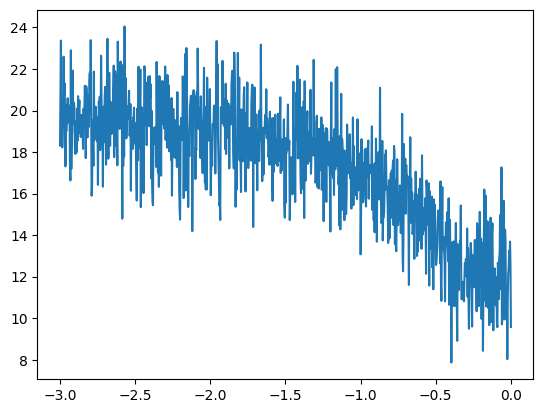

In [183]:
plt.plot(lri, lossi)

### Use the lr

In [184]:
for i in range(10000):   
    # constructing minibatch
    ix = torch.randint(0, X.shape[0], (32,))

    # forward pass
    emb = C[X[ix]]      #[32, 3, 2]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) 
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])
    # print(loss.item())
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # gradient descent
    # lr = lrs[i]
    lr = 0.01
    p.data += -lr * p.grad

    #track stats
    # lri.append(lre[i])
    # lossi.append(loss.item())

print(loss.item())

9.305981636047363


In [185]:
emb = C[X]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) 
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y)
loss

tensor(11.8177, grad_fn=<NllLossBackward0>)

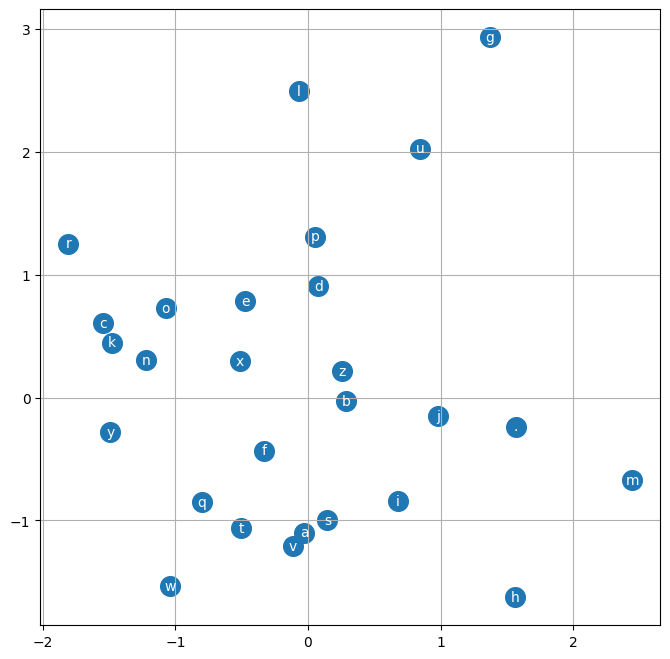

In [186]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

### Splitting dataset

In [187]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y


random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [161]:
C = torch.randn((27, 2))

In [193]:
Xtr.shape, Ytr.shape

(torch.Size([182580, 3]), torch.Size([182580]))

In [194]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [195]:
sum(p.nelement() for p in parameters)

11897

In [196]:
for p in parameters:
  p.requires_grad = True

In [197]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [198]:
lri = []
lossi = []
stepi = []

In [199]:
for i in range(200000):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))
  
  # forward pass
  emb = C[Xtr[ix]] # (32, 3, 10)
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 200)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  #lr = lrs[i]
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

#print(loss.item())

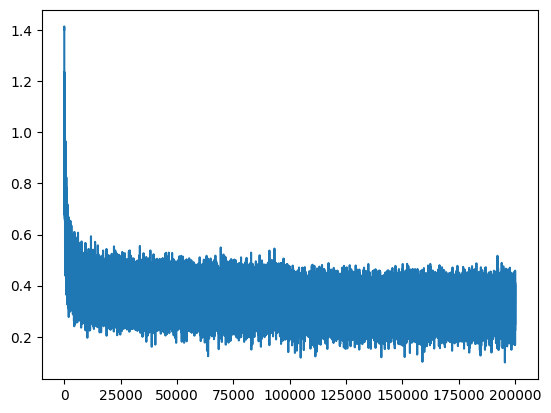

In [200]:
plt.plot(stepi, lossi)

In [201]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1468, grad_fn=<NllLossBackward0>)

In [202]:
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1123, grad_fn=<NllLossBackward0>)

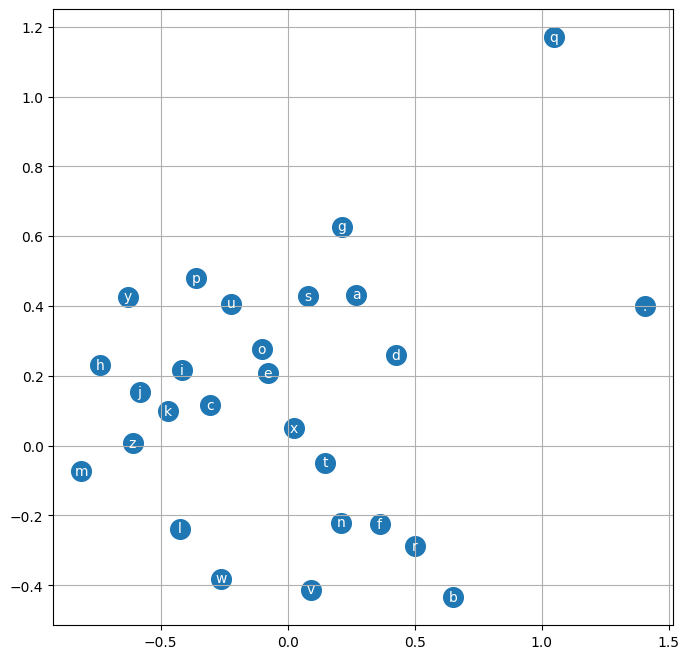

In [203]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [204]:
context = [0] * block_size
C[torch.tensor([context])].shape

torch.Size([1, 3, 10])

### sampling

In [205]:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carmah.
amelle.
khi.
mili.
tatyannah.
sae.
rahnee.
deliah.
jareen.
nellara.
chaiir.
kaleigh.
ham.
prin.
quinn.
sulie.
alian.
quinterri.
jarynn.
jace.
